# Run Sine Sweep to get Transfer Function

In [12]:
import numpy as np
import sounddevice as sd
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def generate_sweep(fs, duration, f_start, f_end):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    sweep = signal.chirp(t, f0=f_start, f1=f_end, t1=duration, method='logarithmic')
    return t, sweep

def measure_system_response(fs, duration, f_start, f_end, input_gain=0.1):
    print("Generating sweep...")
    t, sweep = generate_sweep(fs, duration, f_start, f_end)
    sweep = sweep * input_gain

    print(sd.query_devices())

    print("Playing and recording...")
    recording = sd.playrec(sweep, samplerate=fs, channels=2, dtype='float64')
    sd.wait()
    print("Done recording.")

    return recording[:, 1], recording[:, 0]

def compute_transfer_function_fft(input_signal, output_signal, fs):
    N = len(input_signal)
    window = np.hanning(N)
    input_windowed = input_signal * window
    output_windowed = output_signal * window

    X = np.fft.rfft(input_windowed)
    Y = np.fft.rfft(output_windowed)
    freqs = np.fft.rfftfreq(N, d=1/fs)

    X = np.where(np.abs(X) < 1e-12, 1e-12, X)
    H = Y / X
    return freqs, H

def iir_filter_response(b, a, freqs, fs):
    w = 2 * np.pi * freqs / fs
    _, h = signal.freqz(b, a, worN=w)
    return h

def peaking_eq_biquad(f0, Q, gain_db, fs):
    A = 10**(gain_db / 40)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)

    b0 = 1 + alpha * A
    b1 = -2 * np.cos(w0)
    b2 = 1 - alpha * A
    a0 = 1 + alpha / A
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha / A

    b = np.array([b0, b1, b2]) / a0
    a = np.array([1.0, a1 / a0, a2 / a0])
    return b, a




fs = 44100
duration = 20
f_start = 5
f_end = 10000
filter_order = 16

input_signal, output_signal = measure_system_response(fs, duration, f_start, f_end)
freqs, H_measured = compute_transfer_function_fft(input_signal, output_signal, fs)

valid = (freqs >= f_start) & (freqs <= f_end)
freqs = freqs[valid]
H_measured = H_measured[valid]
H_measured_orig = H_measured




Generating sweep...
>  0 Teensy MIDI_Audio, Core Audio (2 in, 0 out)
<  1 Teensy MIDI_Audio, Core Audio (0 in, 2 out)
   2 MacBook Pro Microphone, Core Audio (1 in, 0 out)
   3 MacBook Pro Speakers, Core Audio (0 in, 2 out)
   4 Microsoft Teams Audio, Core Audio (1 in, 1 out)
   5 ZoomAudioDevice, Core Audio (2 in, 2 out)
   6 Teensy & HP, Core Audio (0 in, 0 out)
   7 Aggregate Device, Core Audio (0 in, 0 out)
   8 Teensy and Speakers, Core Audio (0 in, 2 out)
   9 teensy io combined, Core Audio (0 in, 0 out)
  10 HaptiCoupler n Speakers, Core Audio (2 in, 4 out)
Playing and recording...
Done recording.


# Find peaking biquad parameters to fit resonance

In [13]:
def fit_peaking_eq_q_only(freqs, target_H, fs, fit_freq_range=None):
    if fit_freq_range is not None:
        fmin, fmax = fit_freq_range
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_fit = freqs[mask]
        target_H_fit = target_H[mask]
    else:
        freqs_fit = freqs
        target_H_fit = target_H

    mags = np.abs(target_H_fit)
    min_idx = np.argmin(mags)
    min_gain = 20 * np.log10(np.mean(mags[min_idx - 1 : min_idx + 1]))
    f0 = freqs_fit[min_idx]
    gain_db = min_gain

    def q_objective(Q):
        if Q <= 0.05 or Q > 50:
            return 1e6

        b, a = peaking_eq_biquad(f0, Q, gain_db, fs)
        w = 2 * np.pi * freqs_fit / fs
        _, H_fit = signal.freqz(b, a, worN=w)
        error = np.abs(H_fit) - np.abs(target_H_fit)
        return np.sum(error**2)

    result = minimize_scalar(q_objective, bounds=(0.1, 50), method='bounded')
    Q_opt = result.x
    return f0, Q_opt, gain_db

def estimate_wideband_gain(freqs, H_measured, fit_freq_range=None):
    if fit_freq_range is not None:
        fmin, fmax = fit_freq_range
        mask = (freqs >= fmin) & (freqs <= fmax)
        H_subset = H_measured[mask]
    else:
        H_subset = H_measured

    gain_linear = np.mean(np.abs(H_subset))
    gain_db = 20 * np.log10(gain_linear)
    return gain_db

# --- Estimate and normalize wideband gain ---
fit_wb_range = (10, 40)
wb_gain_db = estimate_wideband_gain(freqs, H_measured_orig, fit_wb_range)
print(f"Estimated Wideband Gain: {wb_gain_db:.2f} dB")
H_measured = H_measured_orig / (10**(wb_gain_db / 20))

fit_freq_range = (15, 600)
f0, Q, gain_db = fit_peaking_eq_q_only(freqs, H_measured, fs, fit_freq_range)
b_fit, a_fit = peaking_eq_biquad(f0, Q, gain_db, fs)
_, H_fit = signal.freqz(b_fit, a_fit, worN=2 * np.pi * freqs / fs)

print(f"Fitted Peaking EQ:\n  f0 = {f0:.1f} Hz\n  Q = {Q:.2f}\n  Gain = {gain_db:.2f} dB")

Estimated Wideband Gain: -2.06 dB
Fitted Peaking EQ:
  f0 = 72.8 Hz
  Q = 3.95
  Gain = -20.16 dB


# Find inductance filtering coefficients

In [14]:
import numpy as np
import sounddevice as sd
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


def iir_filter_response(b, a, freqs, fs):
    w = 2 * np.pi * freqs / fs
    _, h = signal.freqz(b, a, worN=w)
    return h

def smooth_magnitude(freqs, magnitude, smoothing_octaves=0.1):
    smoothed = np.zeros_like(magnitude)
    for i, f in enumerate(freqs):
        if f <= 0:
            smoothed[i] = magnitude[i]
            continue
        f_low = f * 2**(-smoothing_octaves / 2)
        f_high = f * 2**(smoothing_octaves / 2)
        mask = (freqs >= f_low) & (freqs <= f_high)
        if np.any(mask):
            smoothed[i] = np.mean(magnitude[mask])
        else:
            smoothed[i] = magnitude[i]
    return smoothed

def peaking_eq_biquad(f0, Q, gain_db, fs):
    """
    Standard RBJ peaking EQ biquad.

    Returns (b, a) with a0 normalized to 1.0.
    """
    A = 10**(gain_db / 40)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)

    b0 =   1 + alpha * A
    b1 =  -2 * np.cos(w0)
    b2 =   1 - alpha * A
    a0 =   1 + alpha / A
    a1 =  -2 * np.cos(w0)
    a2 =   1 - alpha / A

    # normalize
    b = np.array([b0, b1, b2]) / a0
    a = np.array([1.0, a1 / a0, a2 / a0])
    return b, a

# ---------------- New fitting code: fixed peaking + tuned biquad ----------------

def tuned_biquad_response(params, w):
    """
    params = [b0, b1, b2, r, theta]
    """
    b0, b1, b2, p_r, p_theta = params

    r = np.clip(p_r, 0.0, 0.9999)
    theta = np.clip(p_theta, 0.0, np.pi)

    a1 = -2.0 * r * np.cos(theta)
    a2 = r**2

    jw = np.exp(-1j * w)

    num = b0 + b1 * jw + b2 * (jw**2)
    den = 1.0 + a1 * jw + a2 * (jw**2)

    return num / den


def cascade_response_fixed_peak(params, w, H_peak):
    """
    Total response = fixed peaking EQ * optimized biquad
    """
    H2 = tuned_biquad_response(params, w)
    return H_peak * H2


def residuals_fixed_peak(params, w, H_target, H_peak, mag_only=False):
    """
    Residuals for optimizer
    """
    H_est = cascade_response_fixed_peak(params, w, H_peak)

    if mag_only:
        return np.abs(H_est) - np.abs(H_target)
    else:
        return np.concatenate([
            np.real(H_est - H_target),
            np.imag(H_est - H_target)
        ])


def fit_fixed_peak_plus_biquad(
        freqs,
        H_target,
        fs,
        peak_f0,
        peak_Q,
        peak_gain_db,
        fit_freq_range=None,
        mag_only=False):

    if fit_freq_range is not None:
        fmin, fmax = fit_freq_range
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_fit = freqs[mask]
        H_fit = H_target[mask]
    else:
        freqs_fit = freqs
        H_fit = H_target

    w = 2.0 * np.pi * freqs_fit / fs

    # fixed peaking EQ
    b_peak, a_peak = peaking_eq_biquad(peak_f0, peak_Q, peak_gain_db, fs)
    H_peak = iir_filter_response(b_peak, a_peak, freqs_fit, fs)

    # ---- Initial guess for tunable biquad ----
    x0 = np.array([
        1.0, 0.0, 0.0,  # numerator
        0.8,            # pole radius
        np.pi/8         # pole angle
    ])

    lower = [-np.inf, -np.inf, -np.inf, 0.0, 0.0]
    upper = [ np.inf,  np.inf,  np.inf, 0.9999, np.pi]

    result = least_squares(
        residuals_fixed_peak,
        x0,
        args=(w, H_fit, H_peak, mag_only),
        bounds=(lower, upper),
        method='trf',
        max_nfev=4000,
        verbose=1
    )

    b0, b1, b2, pr, th = result.x

    r = np.clip(pr, 0.0, 0.9999)
    theta = np.clip(th, 0.0, np.pi)

    a1 = -2.0 * r * np.cos(theta)
    a2 = r**2

    b2_section = np.array([b0, b1, b2])
    a2_section = np.array([1.0, a1, a2])

    # overall cascade
    b_total = np.convolve(b_peak, b2_section)
    a_total = np.convolve(a_peak, a2_section)

    return (
        b_total, a_total,
        (b_peak, a_peak),
        (b2_section, a2_section),
        result
    )

# ---------------- End fitting code ----------------



#MAIN PROG:
fs = 44100
duration = 10
f_start = 5
f_end = 6000
smoothing_octaves = 0.01  # <--- User-adjustable smoothing bandwidth


# --- Smooth magnitude only ---
magnitude_smoothed = smooth_magnitude(freqs, np.abs(H_measured_orig), smoothing_octaves)
phase_smoothed = smooth_magnitude(freqs, np.angle(H_measured_orig), smoothing_octaves)
# preserve measured phase but replace magnitude with smoothed magnitude
#H_measured = magnitude_smoothed * np.exp(1j * np.angle(H_measured))



# --- Fit filter: two cascaded biquads ---
fit_freq_range = (10, 3000)
peak_f0 = 100
peak_Q = 4
peak_gain_db = -20

b_total, a_total, sec1, sec2, opt_result = fit_fixed_peak_plus_biquad(
    freqs,
    H_measured,
    fs,
    f0,
    Q,
    gain_db,
    fit_freq_range,
    mag_only=False
)

b1, a1 = sec1
b2, a2 = sec2

# compute frequency response of fitted cascade
H_fit = iir_filter_response(b_total, a_total, freqs, fs)

# report
print("\nFitted cascade biquad coefficients (overall, a0 normalized to 1):")
print(f"b_total = {b_total}")
print(f"a_total = {a_total}")

print("\nSection 1 (b, a):")
print(f"b1 = {b1}")
print(f"a1 = {a1}")
poles1 = np.roots(a1)
print(f"Poles section 1: {poles1}, magnitudes: {np.abs(poles1)}")

print("\nSection 2 (b, a):")
print(f"b2 = {b2}")
print(f"a2 = {a2}")
poles2 = np.roots(a2)
print(f"Poles section 2: {poles2}, magnitudes: {np.abs(poles2)}")

# overall poles
poles_total = np.roots(a_total)
print("\nOverall poles:", poles_total)
print("Overall pole magnitudes:", np.abs(poles_total))
if np.all(np.abs(poles_total) < 1.0 + 1e-12):
    print("Stability check: OK (all poles inside unit circle).")
else:
    print("Warning: stability check failed (some poles outside unit circle).")



`ftol` termination condition is satisfied.
Function evaluations 378, initial cost 1.1358e+06, final cost 8.4945e+01, first-order optimality 1.57e+00.

Fitted cascade biquad coefficients (overall, a0 normalized to 1):
b_total = [ 0.1824011  -0.59174281  0.693954   -0.34225712  0.05764623]
a_total = [ 1.         -3.77059302  5.32595861 -3.3400114   0.78464712]

Section 1 (b, a):
b1 = [ 0.99623848 -1.99155143  0.99541994]
a1 = [ 1.         -1.99155143  0.99165842]
Poles section 1: [0.99577572+0.00944151j 0.99577572-0.00944151j], magnitudes: [0.99582048 0.99582048]

Section 2 (b, a):
b2 = [ 0.1830898  -0.22796756  0.05791147]
a2 = [ 1.         -1.77904159  0.79124737]
Poles section 2: [0.88952079+0.00036069j 0.88952079-0.00036069j], magnitudes: [0.88952087 0.88952087]

Overall poles: [0.99577572+0.00944151j 0.99577572-0.00944151j 0.88952079+0.00036069j
 0.88952079-0.00036069j]
Overall pole magnitudes: [0.99582048 0.99582048 0.88952087 0.88952087]
Stability check: OK (all poles inside unit 

In [15]:
smooth_phase = smooth_magnitude(freqs, np.angle(H_measured_orig, deg=True), 0.1)

# Plot the transfer functions of real and modelled

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


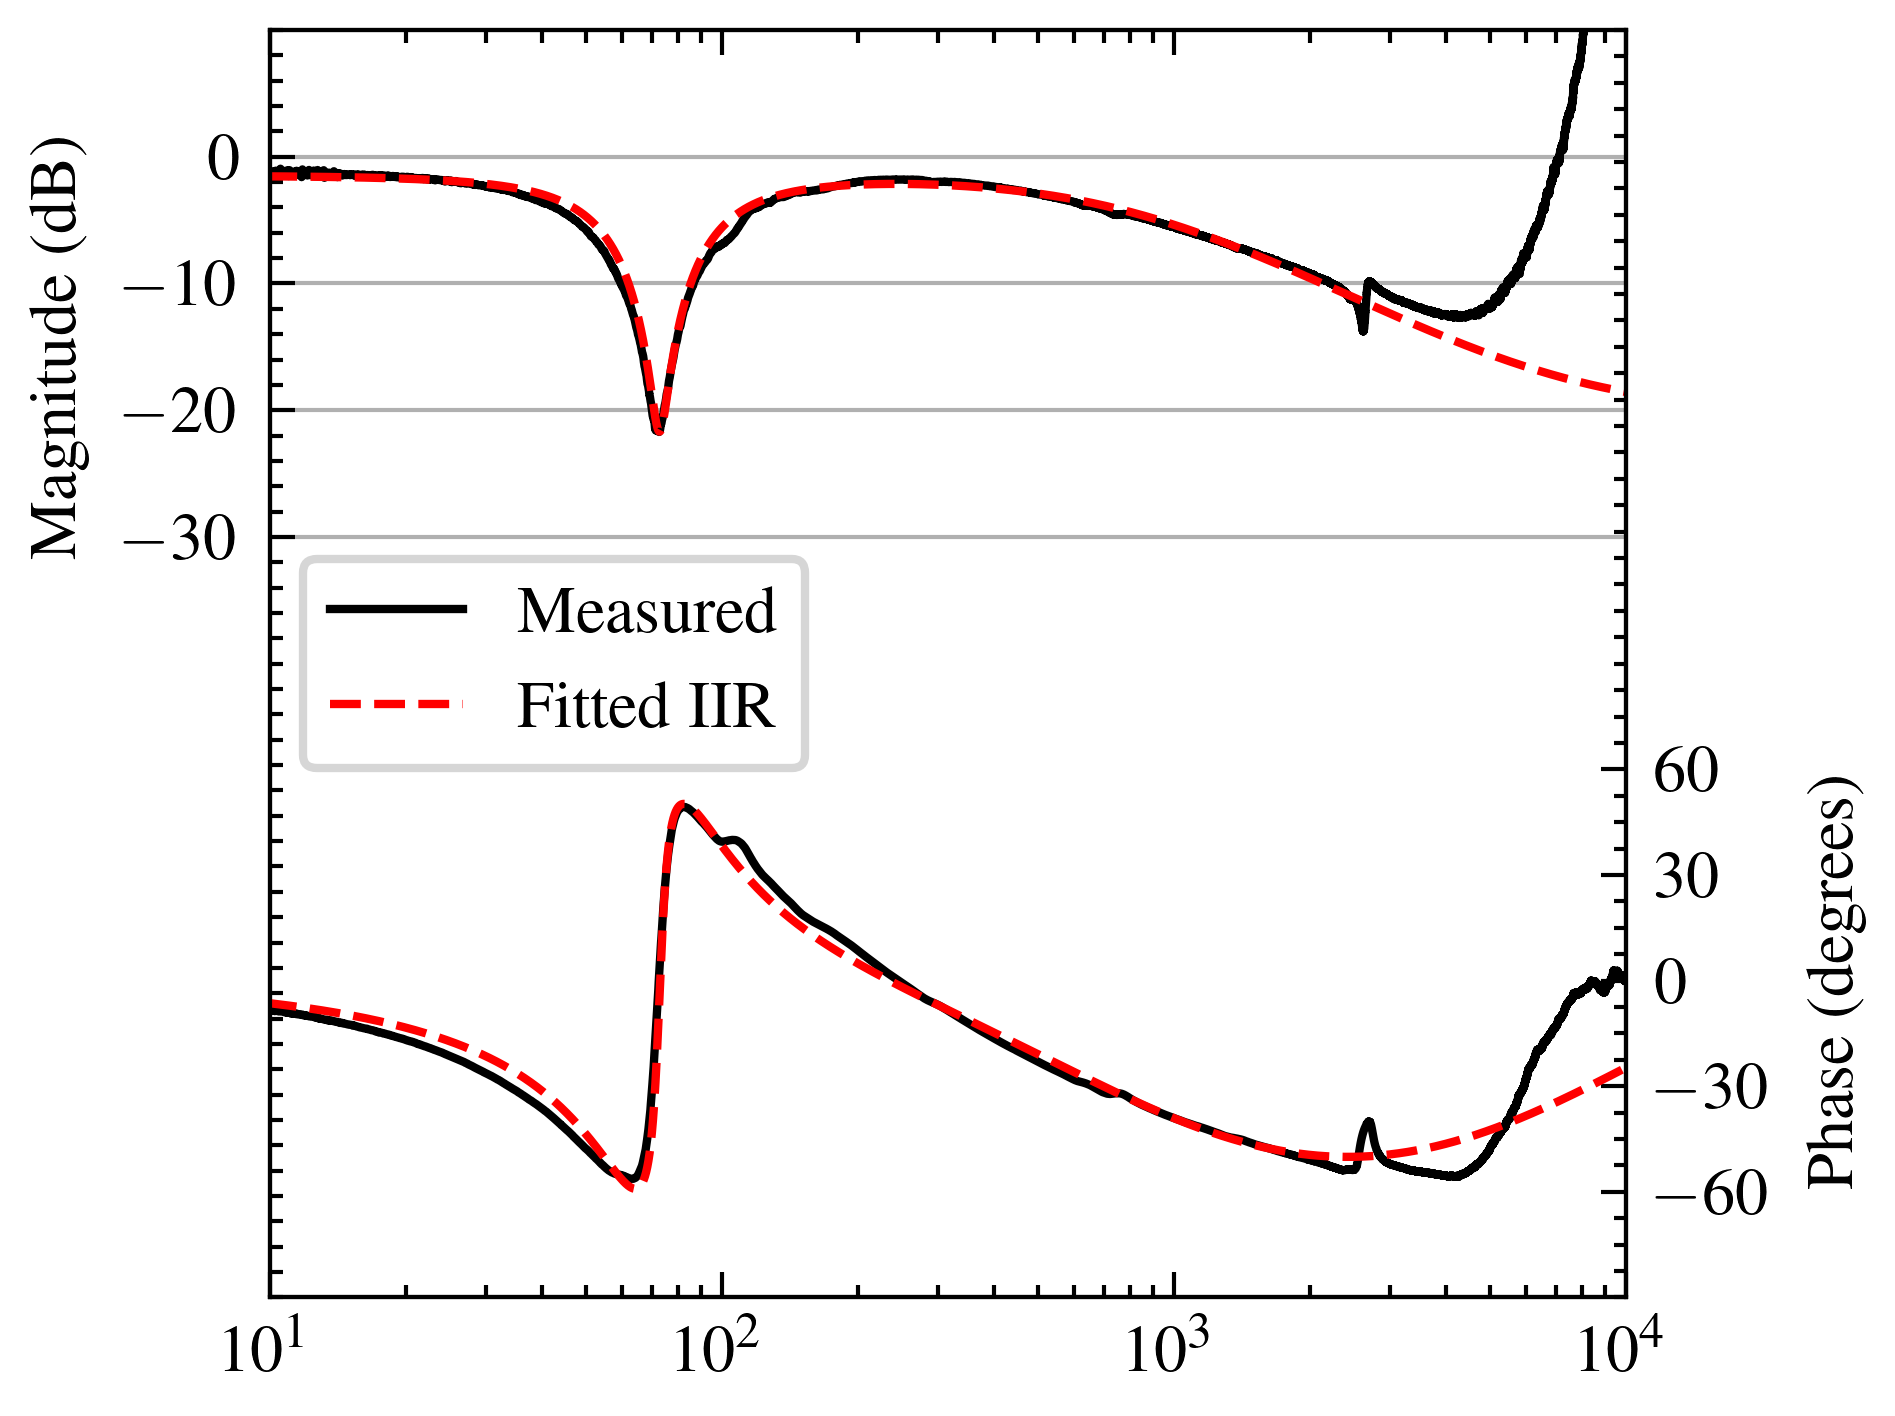

In [16]:
import scienceplots


fig, ax = plt.subplots()
#plt.style.use(['science','ieee'])
ax.set_xlim([10, 10000])



#ax.semilogx(freqs, 20*np.log10(np.abs(H_measured)), label='Measured')
ax.semilogx(freqs, 20*np.log10(np.abs(magnitude_smoothed)), label='Measured')
ax.semilogx(freqs, 20*np.log10(np.abs(H_fit)) + wb_gain_db, '--', label='Fitted IIR')
ax.set_ylabel("Magnitude (dB)")
ax.set_ylim([-90, 10])
ax.set_yticks([-30, -20, -10, 0])
#ax.set_yticks([],minor=True)
ax.yaxis.label.set_position((0.0, 0.75))
ax.grid(axis="y")



ax2 = ax.twinx()
#ax2.semilogx(freqs, np.angle(H_measured_orig, deg=True), label='Measured')
ax2.semilogx(freqs, smooth_phase, label='Measured')
ax2.semilogx(freqs, np.angle(H_fit, deg=True), '--', label='Fitted IIR')
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Phase (degrees)")
ax2.set_ylim([-90, 270])
ax2.set_yticks([-60, -30, 0, 30, 60])
ax2.grid(axis="y")
#ax2.set_yticks([],minor=True)
ax2.yaxis.label.set_position((0.0, 0.25))
#ax2.legend()
plt.grid(True)

#ax.grid(axis="y")


plt.legend(loc='center left',frameon=True)
plt.grid(False)


plt.tight_layout()
plt.savefig('outputs/filter_fitting.eps', format='eps')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


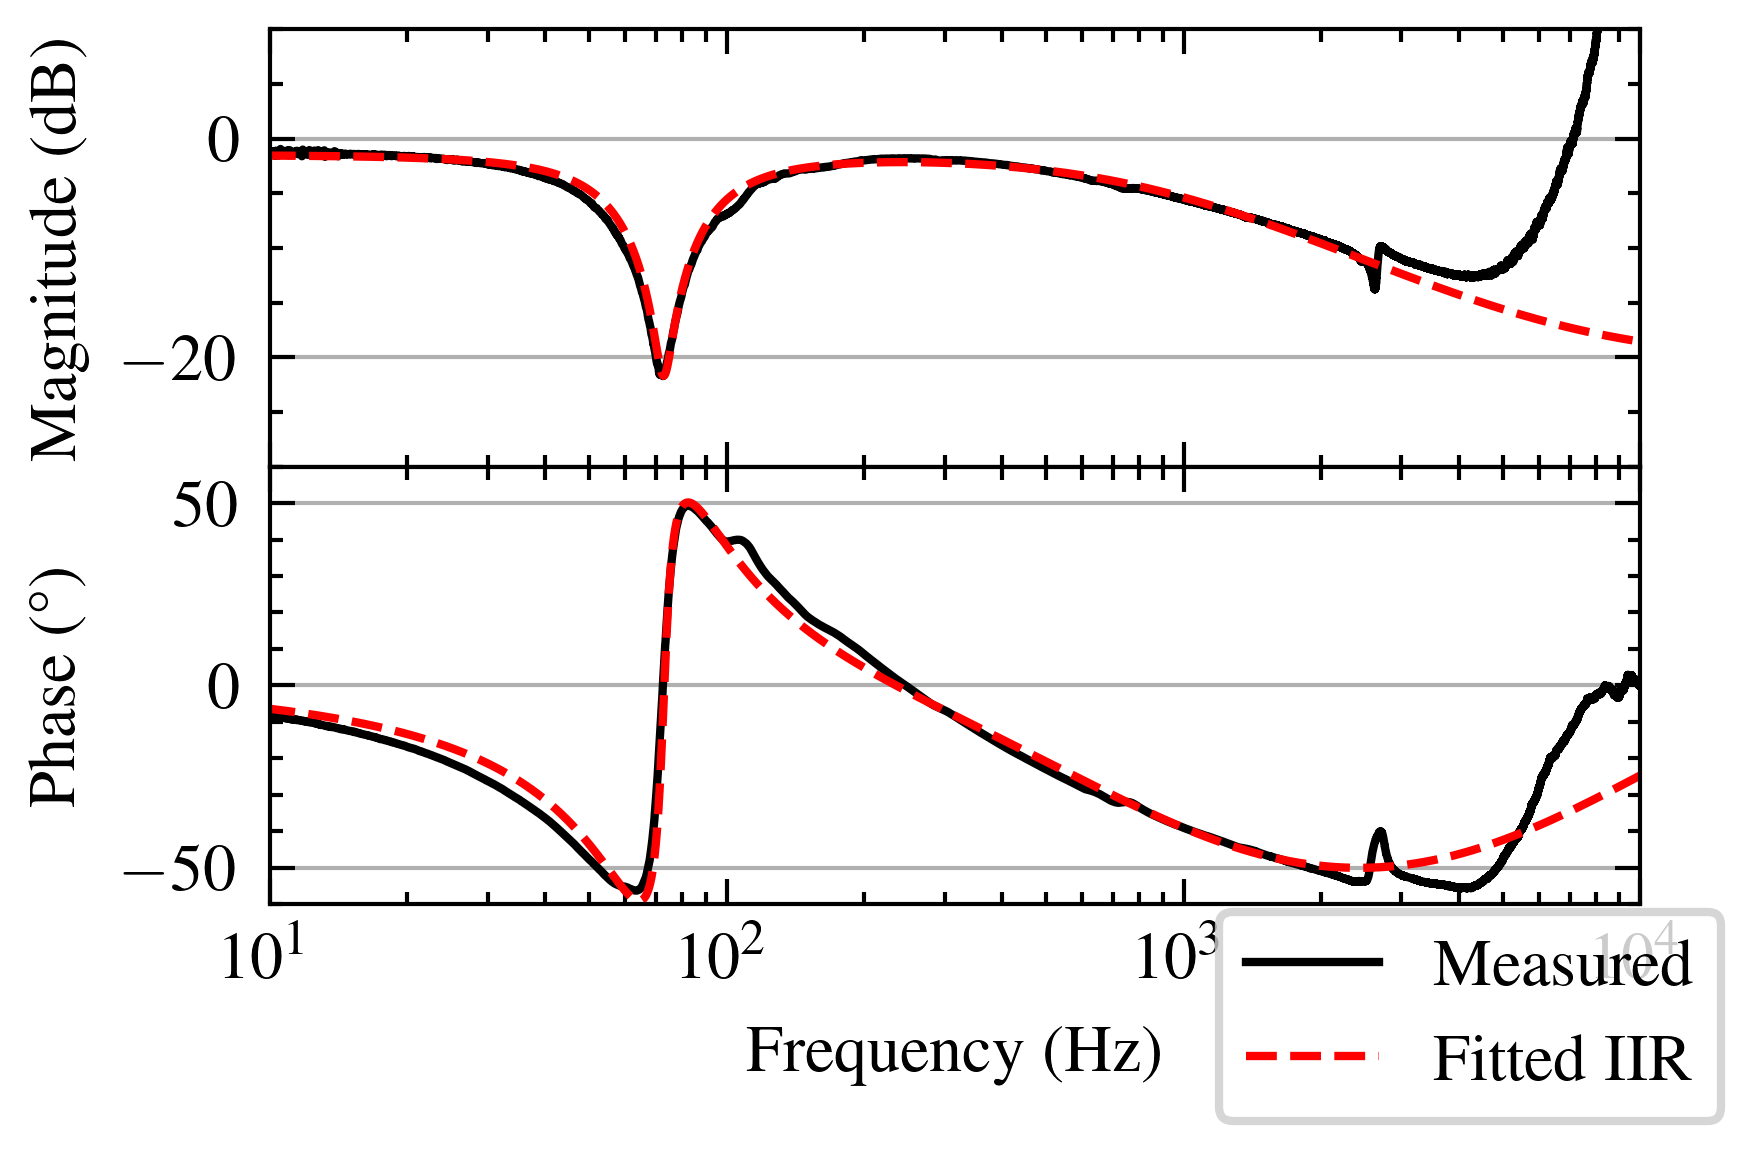

In [17]:
import scienceplots
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(['science', 'ieee'])

fig, (ax_mag, ax_phase) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'hspace': 0},  # no gap between plots
    figsize=(3, 2)
)

# -----------------------
# Magnitude plot (top)
# -----------------------
ax_mag.set_xlim([10, 10000])

# ax_mag.semilogx(freqs, 20*np.log10(np.abs(H_measured)), label='Measured')
line_mag_meas, = ax_mag.semilogx(
    freqs,
    20 * np.log10(np.abs(magnitude_smoothed)),
    label='Measured'
)

line_mag_fit, = ax_mag.semilogx(
    freqs,
    20 * np.log10(np.abs(H_fit)) + wb_gain_db,
    '--',
    label='Fitted IIR'
)

ax_mag.set_ylabel("Magnitude (dB)")
ax_mag.set_ylim([-30, 10])
#ax_mag.set_yticks([-30, -20, -10, 0])
ax_mag.grid(axis="y")

# Hide x tick labels on top plot
ax_mag.tick_params(labelbottom=False)

# -----------------------
# Phase plot (bottom)
# -----------------------
# ax_phase.semilogx(freqs, np.angle(H_measured_orig, deg=True), label='Measured')
ax_phase.semilogx(
    freqs,
    smooth_phase
)

ax_phase.semilogx(
    freqs,
    np.angle(H_fit, deg=True),
    '--'
)

ax_phase.set_xlabel("Frequency (Hz)")
ax_phase.set_ylabel("Phase (°)")
ax_phase.set_ylim([-60, 60])
#ax_phase.set_yticks([-60, -30, 0, 30, 60])
ax_phase.grid(axis="y")

# -----------------------
# Shared legend
# -----------------------
fig.legend(
    [line_mag_meas, line_mag_fit],
    ['Measured', 'Fitted IIR'],
    loc='lower right',
    frameon=True
)

plt.tight_layout()

plt.savefig('outputs/filter_fitting.eps', format='eps')
plt.show()